In [1]:
# Import necessary library for data manipulation
import pandas as pd

# Load the spam dataset directly from the source URL
url = "https://raw.githubusercontent.com/amankharwal/SMS-Spam-Detection/master/spam.csv"
data = pd.read_csv(url, encoding="latin-1")

# Keep only the relevant columns for our model (label and text)
data = data[["class", "message"]]

# Print a success message and the first 5 rows to verify the data
print("Dataset Loaded Successfully! Here is the data:")
print("-" * 50)
print(data.head())

Dataset Loaded Successfully! Here is the data:
--------------------------------------------------
  class                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [2]:
# Import necessary modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Separate the messages (X) and their labels (y)
X = data["message"]
y = data["class"]

# Split the dataset into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize CountVectorizer to convert text into numbers
cv = CountVectorizer()

# Convert the text data into numerical vectors
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

# Print the success message and dimensions
print("Step 2 Completed Successfully!")
print("-" * 50)
print(f"Total training messages: {X_train_cv.shape[0]}")
print(f"Total testing messages: {X_test_cv.shape[0]}")

Step 2 Completed Successfully!
--------------------------------------------------
Total training messages: 4457
Total testing messages: 1115


In [3]:
# Import Multinomial Naive Bayes model and accuracy scoring tool
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Initialize the Multinomial Naive Bayes model
model = MultinomialNB()

# Train (fit) the model using the converted training data
model.fit(X_train_cv, y_train)

# Make predictions on the hidden testing data to evaluate performance
predictions = model.predict(X_test_cv)

# Calculate and print the model's exact accuracy score
accuracy = accuracy_score(y_test, predictions)
print("Step 3 Completed Successfully!")
print("-" * 50)
print(f"Model Training Accuracy: {accuracy * 100:.2f}%")
print("-" * 50)

# --- LIVE TESTING SECTION ---
# You can change these messages to test the AI yourself
custom_messages = [
    "Hey Kursia, don't forget to complete your BCA assignments today.",
    "WINNER!! You have won a free cash prize of Rs. 50,000. Click this link to claim now!"
]

# Convert the custom messages into numerical format using the trained vectorizer
custom_messages_cv = cv.transform(custom_messages)

# Predict whether the custom messages are 'ham' or 'spam'
custom_predictions = model.predict(custom_messages_cv)

# Print the final output of the live testing
print("Live Testing Results:")
print("-" * 50)
for msg, pred in zip(custom_messages, custom_predictions):
    print(f"Message: '{msg}' \nPrediction: --> {pred.upper()}\n")

Step 3 Completed Successfully!
--------------------------------------------------
Model Training Accuracy: 98.39%
--------------------------------------------------
Live Testing Results:
--------------------------------------------------
Message: 'Hey Kursia, don't forget to complete your BCA assignments today.' 
Prediction: --> HAM

Message: 'WINNER!! You have won a free cash prize of Rs. 50,000. Click this link to claim now!' 
Prediction: --> SPAM



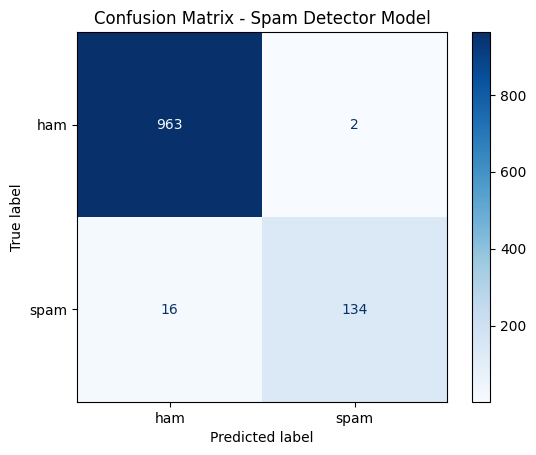

In [4]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix using test labels and model predictions
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

# Setup the visual display with a clean blue color theme
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

# Add a professional title and render the plot
plt.title("Confusion Matrix - Spam Detector Model")
plt.show()

In [5]:
# Take live dynamic input from the user in the console
user_message = input("Enter any message to check for Spam: ")

# Convert the single user text input into a list format for the vectorizer
user_message_cv = cv.transform([user_message])

# Predict whether the message is 'ham' or 'spam'
user_prediction = model.predict(user_message_cv)

# Print the final result in a clean and readable format
print("\n" + "=" * 50)
print(f"Your Input Message: '{user_message}'")
print(f"AI Real-time Prediction: --> {user_prediction[0].upper()}")
print("=" * 50)

Enter any message to check for Spam: Hi kursia

Your Input Message: 'Hi kursia'
AI Real-time Prediction: --> HAM
